<a href="https://colab.research.google.com/github/Santatriniaina17/TP-ML-IGGLIA5/blob/Main/ML_Mall_customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import kagglehub

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

data = pd.read_csv(path + "/Mall_Customers.csv")
data.head()

Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
#supression colonne inutile
data_clean= data.drop(columns=["CustomerID"])

In [ ]:
#encodage des genres
data_clean['Gender'] = data_clean['Gender'].map({'Male': 0, 'Female': 1})

In [ ]:
#standardisation des variables
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaler = StandardScaler()

data_scaled = data_clean.copy()
data_scaled[features]= scaler.fit_transform(data_clean[features])

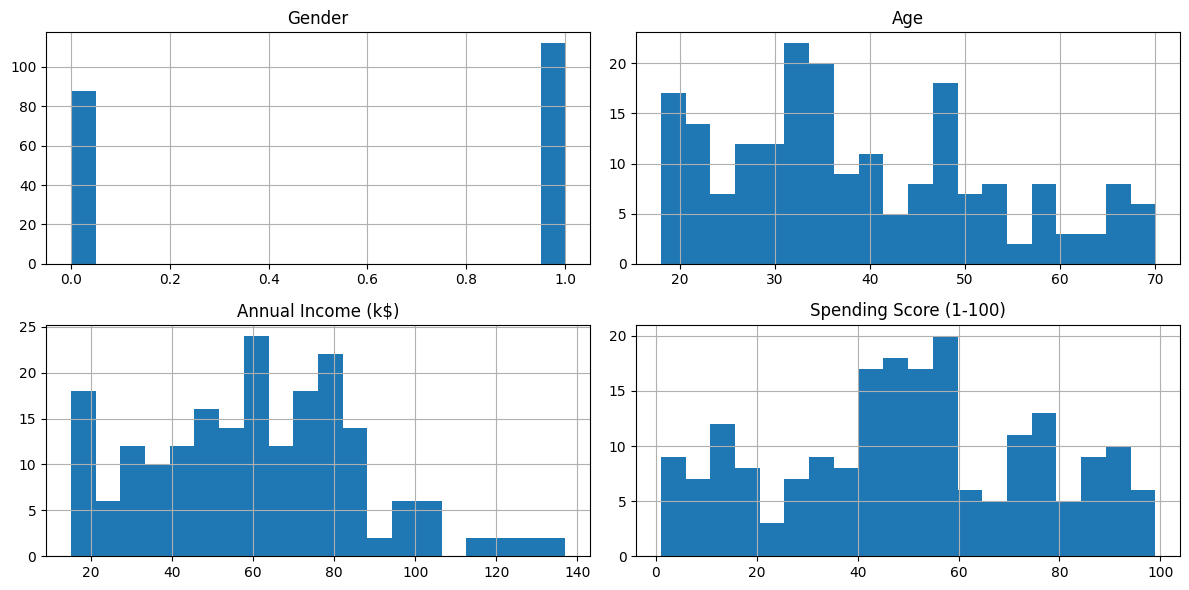

In [ ]:
#EDA Univariée
data_clean.hist(bins=20, figsize=(12, 6))
plt.tight_layout()
plt.show()

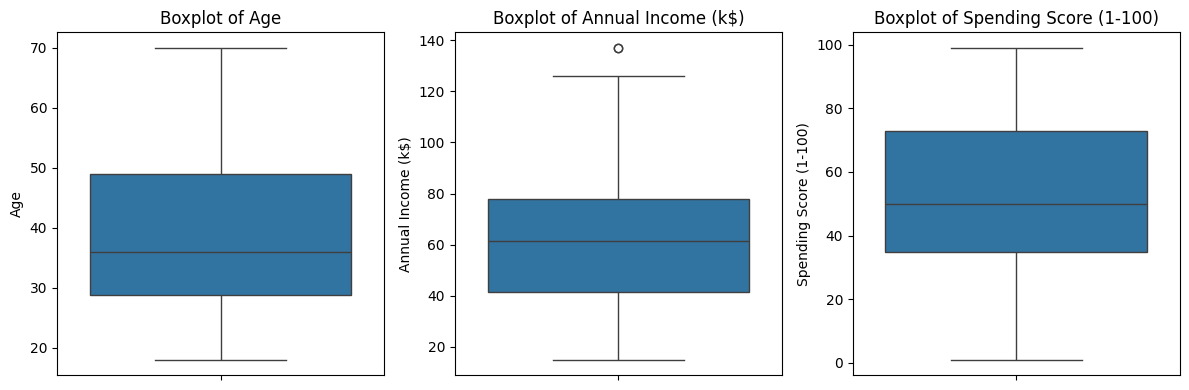

In [ ]:
#BoxPlots
plt.figure(figsize=(12, 4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=data_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

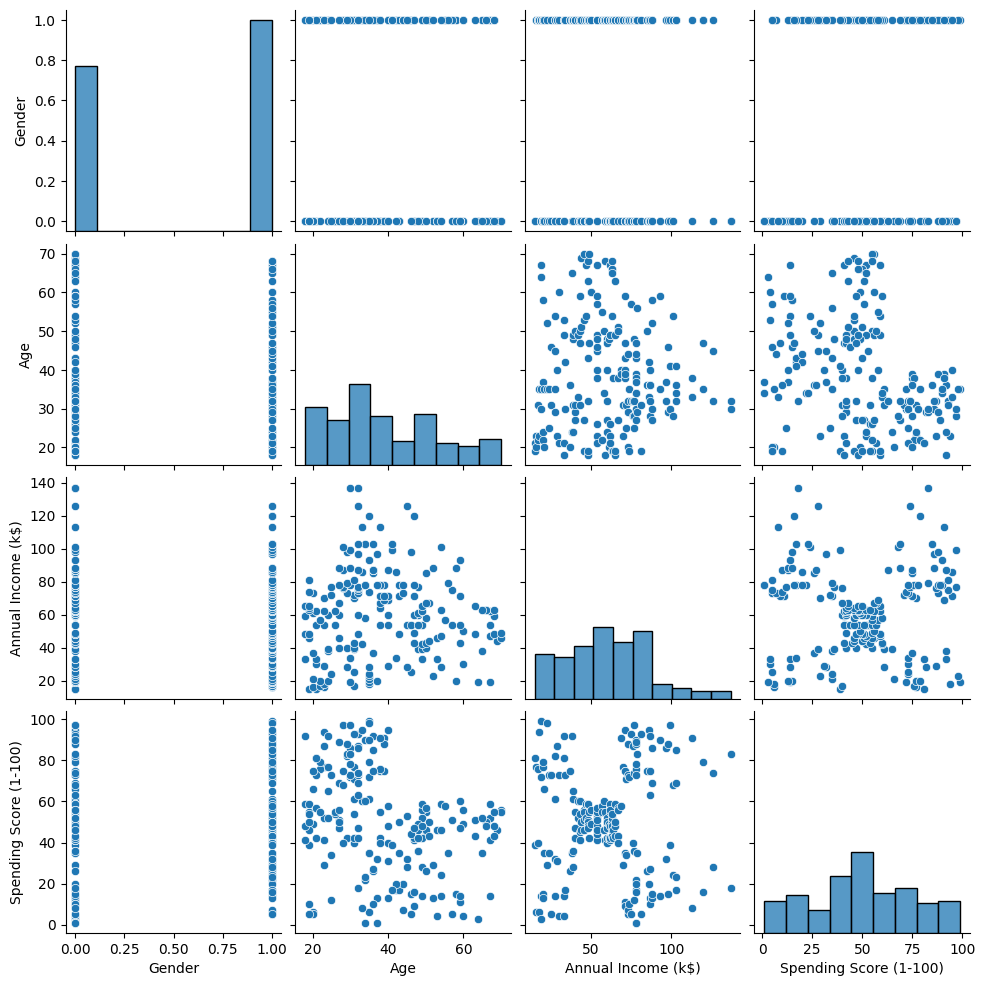

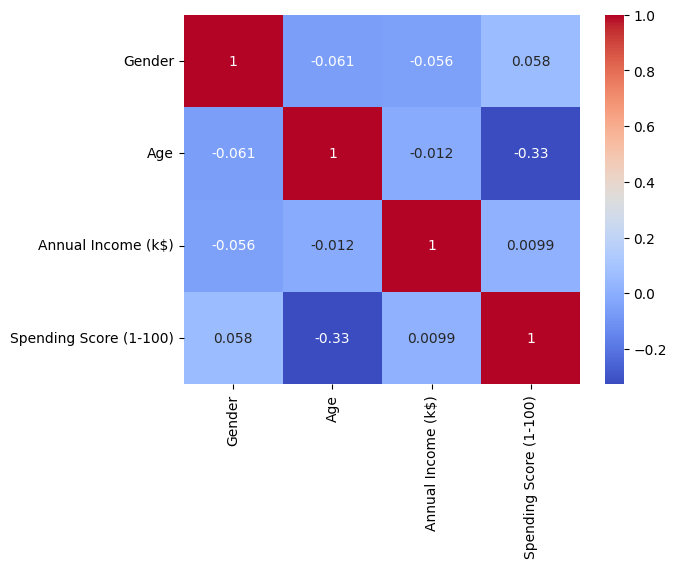

In [ ]:
#Multivarié
sns.pairplot(data_clean)
plt.show()

# Matrice de corrélation
sns.heatmap(data_clean.corr(), annot=True, cmap='coolwarm')
plt.show()


In [ ]:
# Créer une variable d'âge groupé
data_clean['AgeGroup'] = pd.cut(data_clean['Age'], bins=[0, 25, 40, 60, 100], labels=['Jeune', 'Adulte', 'Senior', 'Ainé'])


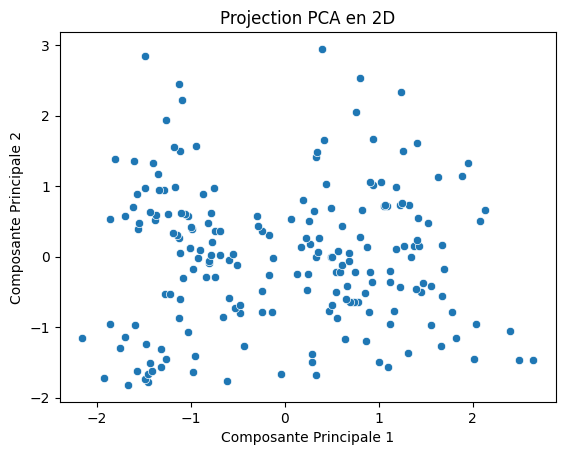

In [ ]:
#Reduction de la dimension
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled[features])
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])


sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.title("Projection PCA en 2D")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.show()


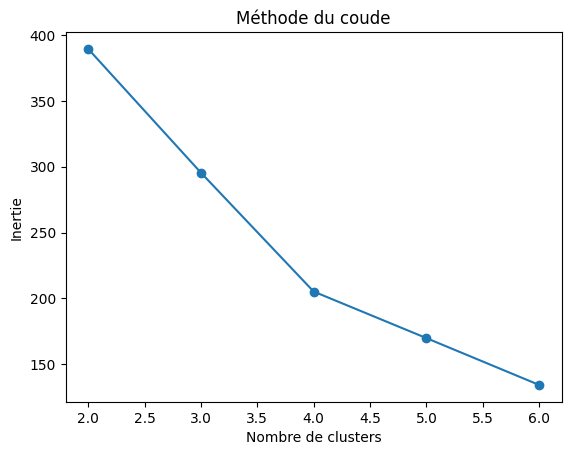

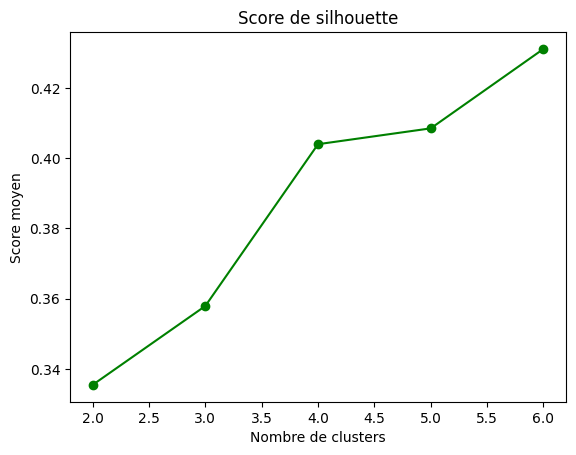

In [ ]:
#Clustering K-means

inertia = []
silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled[features])
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled[features], kmeans.labels_))

# Courbe du coude
plt.plot(range(2, 7), inertia, marker='o')
plt.title('Méthode du coude')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.show()

# Silhouette
plt.plot(range(2, 7), silhouette_scores, marker='o', color='green')
plt.title('Score de silhouette')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score moyen')
plt.show()


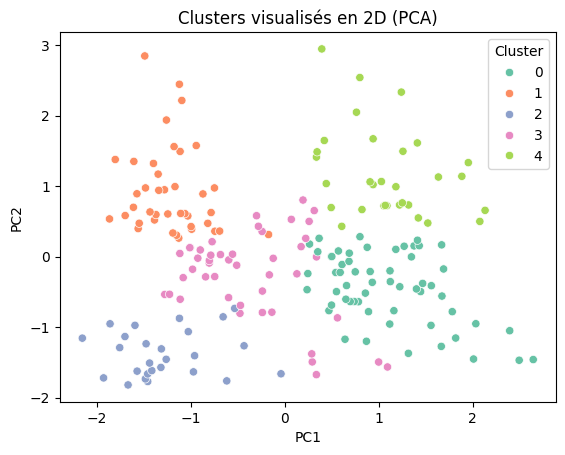

        Age  Annual Income (k$)  Spending Score (1-100)
0  1.178830           -0.493886               -0.329716
1 -0.428806            0.974847                1.216085
2 -0.938764           -1.314731                0.956802
3 -0.869573           -0.238517               -0.360609
4  0.397379            1.115089               -1.231270


In [ ]:
#Interpretation des clusters

# Appliquer le clustering optimal
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
data_scaled['Cluster'] = kmeans.fit_predict(data_scaled[features])

# Visualisation 2D avec PCA
pca_df['Cluster'] = data_scaled['Cluster']
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title('Clusters visualisés en 2D (PCA)')
plt.show()

# Analyse des centroïdes
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print(centroids)



Ce projet avait pour objectif de segmenter les clients d’un centre commercial en groupes homogènes à partir de leur âge, revenu annuel et score de dépense. Après standardisation et exploration des données, une analyse en composantes principales (PCA) a permis de visualiser les clients en 2 dimensions. L’algorithme de K-means, testé avec différentes valeurs de k, a permis d’identifier 5 segments bien distincts.

Parmi ces clusters, on distingue notamment un groupe de jeunes à fort pouvoir d’achat et gros dépensiers, un autre de clients à fort revenu mais peu dépensiers, ou encore des clients plus âgés à faible revenu. Ces profils pourraient être utilisés pour mettre en place des campagnes marketing ciblées (ex : fidélisation, promotions adaptées).

La séparation visuelle entre les groupes est globalement satisfaisante. Pour aller plus loin, il serait intéressant d’ajouter des variables comportementales ou de tester d’autres méthodes de clustering (DBSCAN, Agglomératif). Le modèle offre ainsi une base solide pour mieux comprendre les comportements clients et orienter les décisions stratégiques du centre commercial.